In [59]:
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
#MNIST 데이터에 대한 분류 모델을 구축하라.

test_data = pd.read_csv('/content/drive/MyDrive/test.csv')
train_data = pd.read_csv('/content/drive/MyDrive/train.csv')

x = train_data.iloc[:, 1:]
y = train_data.iloc[:, 0]

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)


print(f"x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_val: {x_val.shape}, y_val: {y_val.shape}")

x_train: (33600, 784), y_train: (33600,)
x_val: (8400, 784), y_val: (8400,)


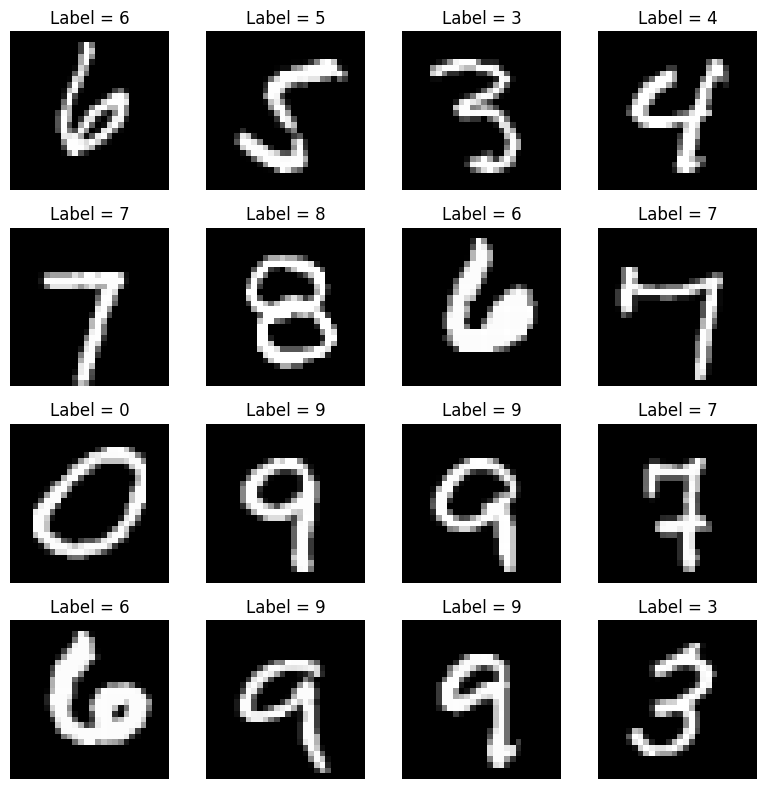

In [62]:
#1 Image 샘플 시각화
import matplotlib.pyplot as plt

fig, ax = plt.subplots(4, 4, figsize=(8, 8))
for i in range(4):
    for j in range(4):
        idx = i * 4 + j
        ax[i, j].imshow(x_train.iloc[idx].values.reshape(28, 28), cmap='gray')
        ax[i, j].set_title(f"Label = {y_train.iloc[idx]}")
        ax[i, j].axis('off')
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Model accuracy is 0.918


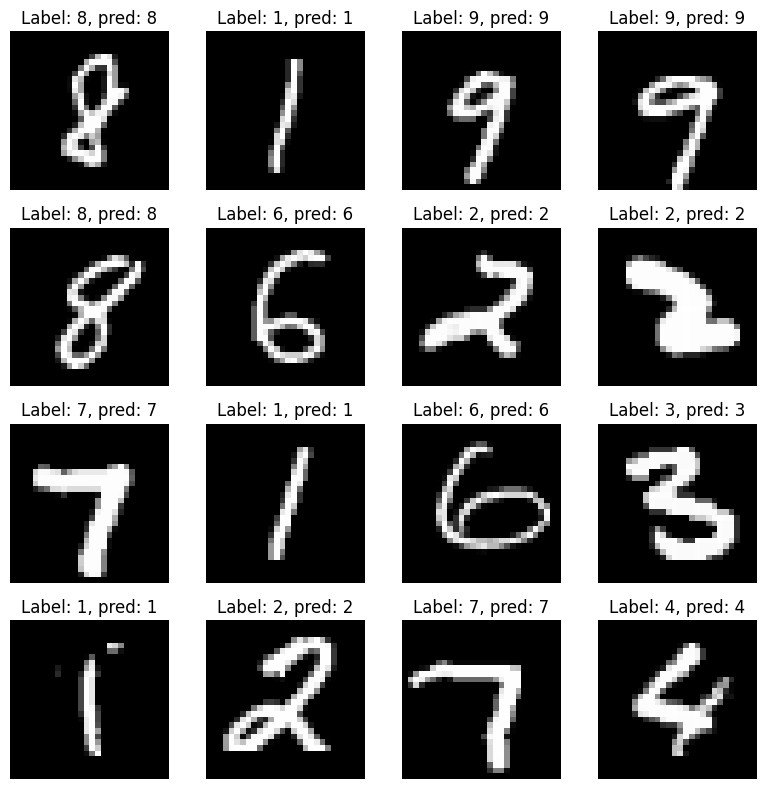

In [75]:
# 2. Scikit-learn을 이용해서 모델 학습
clf = LogisticRegression(
    C=1.0, class_weight=None, dual=False, fit_intercept=True,
    intercept_scaling=1, l1_ratio=None, max_iter=100,
    multi_class='multinomial', n_jobs=None, penalty='l2',
    random_state=None, solver='lbfgs', tol=0.001, verbose=0,
    warm_start=False
)
clf.fit(x_train, y_train)

# 3. 검증 데이터 예측 및 정확도 평가
from sklearn.metrics import accuracy_score
y_val_pred = clf.predict(x_val)
print(f"Model accuracy is {accuracy_score(y_val, y_val_pred):.3f}")

# 4. 올바르게 분류한 이미지를 시각화
mask = y_val == y_val_pred
x_val_correct = x_val[mask]
y_val_correct = y_val[mask].reset_index(drop=True)
y_val_pred_correct = y_val_pred[mask]  # NumPy 배열이면 OK

fig, ax = plt.subplots(4, 4, figsize=(8, 8))
for i in range(4):
    for j in range(4):
        idx = i * 4 + j
        if idx >= len(x_val_correct):
            ax[i, j].axis('off')
            continue
        ax[i, j].imshow(x_val_correct[idx].reshape(28, 28), cmap='gray')
        ax[i, j].set_title(f"Label: {int(y_val_correct[idx])}, pred: {int(y_val_pred_correct[idx])}")
        ax[i, j].axis('off')

plt.tight_layout()
plt.show()



Incorrectly predicted images:


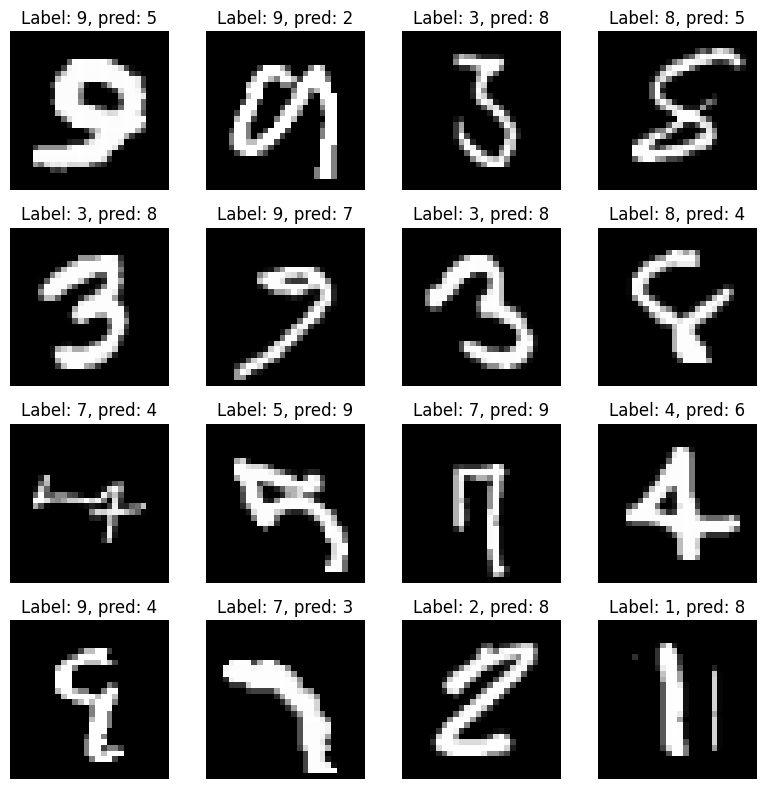

In [76]:
# 5. 잘못 분류한 이미지를 시각화
print("Incorrectly predicted images:")

# 마스크 생성 (예측이 실제값과 다른 경우)
mask_incorrect = y_val != y_val_pred

# 잘못 예측한 경우만 추출
x_val_incorrect = x_val[mask_incorrect]
y_val_incorrect = y_val[mask_incorrect].reset_index(drop=True)
y_val_pred_incorrect = y_val_pred[mask_incorrect]

fig, ax = plt.subplots(4, 4, figsize=(8, 8))

for i in range(4):
    for j in range(4):
        idx = i * 4 + j
        if idx >= len(x_val_incorrect):
            ax[i, j].axis('off')
            continue
        ax[i, j].imshow(x_val_incorrect[idx].reshape(28, 28), cmap='gray')
        ax[i, j].set_title(f"Label: {int(y_val_incorrect[idx])}, pred: {int(y_val_pred_incorrect[idx])}")
        ax[i, j].axis('off')

plt.tight_layout()
plt.show()


In [85]:
# 예시: MNIST test 데이터 불러오기
x_test = pd.read_csv('/content/drive/MyDrive/test.csv')

# 이미지 데이터만 추출 (ImageId 열 제외)
x_test = x_test.values  # 또는 x_test.iloc[:, 1:].values (필요시)

# 크기 확인
print(x_test.shape)  # (28000, 784) 이어야 함

preds = clf.predict(x_test)
sample_submission['Label'] = preds
sample_submission.to_csv('/content/drive/MyDrive/sample_submission.csv', index=False)


(28000, 784)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
